# Predicción de retrasos en vuelos comerciales
Grupo 11: Mikel Lorite, Adrián Izquierdo y Jon Alba

# 1. Contexto y objetivos del proyecto
El contexto de este proyecto se enmarca en la industria de la aviación comercial, un sector que genera cantidades masivas de datos diariamente y donde la puntualidad operativa es un factor crítico. Para llevar a cabo este estudio, utilizamos el conjunto de datos "2015 Flight Delays and Cancellations", publicado originalmente por la Oficina de Estadísticas de Transporte (Bureau of Transportation Statistics) del Departamento de Transporte de los Estados Unidos (DOT). Este dataset rastrea el rendimiento y la puntualidad de los vuelos domésticos operados por las grandes aerolíneas comerciales dentro del país durante el año 2015.

El objetivo principal de nuestro trabajo es construir un modelo predictivo escalable utilizando Apache Spark que permita anticipar si un vuelo sufrirá un retraso significativo a su llegada. A través de este análisis, buscamos identificar patrones subyacentes en las demoras, respondiendo a preguntas sobre qué factores —como la aerolínea, las infraestructuras de origen/destino o las franjas horarias— inciden en la probabilidad de que un vuelo no cumpla con su horario programado. Adicionalmente, desde la perspectiva de la Ingeniería de Datos, el proyecto tiene como meta evaluar la eficiencia computacional de diversos algoritmos de clasificación binaria (Regresión Logística, Random Forest y Gradient-Boosted Trees) frente a un escenario de alto volumen de datos, midiendo y documentando empíricamente la escalabilidad del clúster a través de pruebas de speed-up y size-up.

# 2. Descripción de los datos 
El conjunto de datos seleccionado representa un volumen de información de gran magnitud, ideal para el procesamiento distribuido. En su totalidad, consta de más de 5,8 millones de registros (5.819.079 observaciones empíricas) estructurados originalmente en 31 variables. Para garantizar la integridad relacional de la información, el dataset se divide en tres archivos en formato CSV independientes pero interconectados:

* flights.csv: Constituye el núcleo central de la información, recogiendo el registro individual de cada vuelo operado durante el año. Entre sus variables métricas y categóricas se incluye información temporal exhaustiva (fecha, horarios de salida y llegada programados frente a los reales) e indicadores de rendimiento operativo. La variable clave para nuestro problema de clasificación subyace en la columna de retraso a la llegada (Arrival Delay), que nos indica en minutos la diferencia respecto al horario previsto.

* airlines.csv: Funciona como una tabla de dimensión o diccionario. Contiene el mapeo directo entre los identificadores de código IATA y el nombre comercial estandarizado de cada compañía aérea, lo que resulta fundamental para la posterior visualización e interpretación de los modelos.

* airports.csv: Actúa como un catálogo geográfico detallado. Este archivo permite enriquecer los datos de los vuelos enlazando los códigos IATA de los aeropuertos de origen y destino con su ubicación física. Proporciona variables demográficas y geoespaciales clave como la ciudad, el estado, la latitud y la longitud, abriendo la puerta a capturar el impacto de la congestión regional en nuestras predicciones.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os


spark = SparkSession.builder.appName("FlightDelays").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/11 19:08:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import pyspark.sql.functions as F

df_flights = spark.read.csv("data/flights.csv", header=True, inferSchema=True)
df_airlines = spark.read.csv("data/airlines.csv", header=True, inferSchema=True)
df_airports = spark.read.csv("data/airports.csv", header=True, inferSchema=True)

# Datasets externos
df_wind = spark.read.csv("data/wind_speed.csv", header=True, inferSchema=True)
df_temp = spark.read.csv("data/temperature.csv", header=True, inferSchema=True)
df_desc = spark.read.csv("data/weather_description.csv", header=True, inferSchema=True)

print(f"Total de vuelos iniciales: {df_flights.count():,}")

26/05/11 19:08:44 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Total de vuelos iniciales: 5,819,079


In [3]:
#unir las tablas por IATA CODE

df_airlines = df_airlines.withColumnRenamed("AIRLINE", "AIRLINE_NAMES")
df_joined = df_flights.join(
    F.broadcast(df_airlines), 
    df_flights.AIRLINE == df_airlines.IATA_CODE, 
    "left"
).drop("IATA_CODE") 

df_airports_orig = df_airports.select(
    F.col("IATA_CODE").alias("ORIGIN_IATA"),
    F.col("LATITUDE").alias("ORIGIN_LAT"),
    F.col("LONGITUDE").alias("ORIGIN_LONG")
)

df_joined = df_joined.join(
    F.broadcast(df_airports_orig), 
    df_joined.ORIGIN_AIRPORT == df_airports_orig.ORIGIN_IATA, 
    "left"
).drop("ORIGIN_IATA")

In [4]:
df_joined.show()

26/05/11 19:09:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+--------+---------+-------+-----------------+------------+-------------+--------+---------+-------------------+----------------+--------------+-------------+-------------------+-------------+--------------------+----------+-----------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|FLIGHT_NUMBER|TAIL_NUMBER|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_TIME|DEPARTURE_DELAY|TAXI_OUT|WHEELS_OFF|SCHEDULED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|WHEELS_ON|TAXI_IN|SCHEDULED_ARRIVAL|ARRIVAL_TIME|ARRIVAL_DELAY|DIVERTED|CANCELLED|CANCELLATION_REASON|AIR_SYSTEM_DELAY|SECURITY_DELAY|AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|WEATHER_DELAY|       AIRLINE_NAMES|ORIGIN_LAT|ORIGIN_LONG|
+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+-

# 3. Explicación de Variables

El archivo `flights.csv` de este conjunto de datos contiene 31 variables que detallan el rendimiento, los tiempos y las causas de retrasos de los vuelos comerciales. Se observan los siguientes atributos:

### Identificación y Fechas
*   **YEAR, MONTH, DAY:** Año, mes y día en el que se realizó el vuelo. *(Unidad: Numérico)*
*   **DAY_OF_WEEK:** Día de la semana del vuelo. *(Unidad: Numérico, del 1=Lunes al 7=Domingo)*
*   **AIRLINE:** Aerolínea que opera el vuelo. *(Unidad: Texto, código IATA de 2 letras, ej. "AA" para American Airlines)*
*   **FLIGHT_NUMBER:** Número identificador del vuelo. *(Unidad: Numérico)*
*   **TAIL_NUMBER:** Número de matrícula (registro) del avión específico. *(Unidad: Texto)*
*   **ORIGIN_AIRPORT / DESTINATION_AIRPORT:** Aeropuerto de origen y destino final. *(Unidad: Texto, código IATA de 3 letras, ej. "LAX")*

### Tiempos y Horarios (Programados y Reales) 
La unidad es de horario 24 horas (ej. 1430 = 2:30 PM)
*   **SCHEDULED_DEPARTURE:** Hora a la que el avión debía salir de la puerta de embarque según el itinerario.
*   **DEPARTURE_TIME:** Hora real en la que el avión se desconectó y empezó a moverse desde la puerta de embarque.
*   **WHEELS_OFF:** Hora exacta en la que el avión despegó y sus ruedas dejaron de tocar la pista.
*   **WHEELS_ON:** Hora exacta en la que las ruedas del avión tocaron la pista de aterrizaje en el destino.
*   **SCHEDULED_ARRIVAL:** Hora a la que el avión debía llegar a su puerta de embarque final.
*   **ARRIVAL_TIME:** Hora real en la que el avión llegó y se estacionó en la puerta de destino.



### Duración y Distancia
*   **TAXI_OUT:** Tiempo transcurrido desde que el avión deja la puerta de embarque hasta que logra despegar (`WHEELS_OFF`). *(Unidad: Minutos)*
*   **AIR_TIME:** Tiempo real que el avión pasó volando (en el aire). *(Unidad: Minutos)*
*   **TAXI_IN:** Tiempo transcurrido desde que el avión aterriza (`WHEELS_ON`) hasta que se estaciona en la puerta de embarque. *(Unidad: Minutos)*
*   **SCHEDULED_TIME:** Duración total del viaje (de puerta a puerta) planeada originalmente. *(Unidad: Minutos)*
*   **ELAPSED_TIME:** Duración total real del viaje (equivale a sumar `TAXI_OUT` + `AIR_TIME` + `TAXI_IN`). *(Unidad: Minutos)*
*   **DISTANCE:** Distancia geográfica recorrida entre los aeropuertos. *(Unidad: Millas)*

### Retrasos y Cancelaciones
*   **DEPARTURE_DELAY:** Diferencia entre la salida real y la programada. *(Unidad: Minutos; un número negativo indica que salió antes de tiempo).*
*   **ARRIVAL_DELAY:** Diferencia entre la llegada real y la programada. *(Unidad: Minutos; un número negativo indica que llegó adelantado).*
*   **DIVERTED:** Indica si el vuelo tuvo que ser desviado a un aeropuerto diferente al planeado. *(Unidad: Binario; 1 = Sí, 0 = No)*
*   **CANCELLED:** Indica si el vuelo fue cancelado por completo. *(Unidad: Binario; 1 = Sí, 0 = No)*
*   **CANCELLATION_REASON:** Motivo de la cancelación del vuelo. *(Unidad: Letra; A = Aerolínea, B = Clima, C = Sistema de Tráfico Aéreo, D = Seguridad)*

**Desglose de Retrasos (Causas específicas)**
*Estas columnas solo registran valores si el retraso total del vuelo superó los 15 minutos.*
*   **AIR_SYSTEM_DELAY:** Retrasos controlados por el sistema nacional de tráfico aéreo (ej. mucho tráfico de vuelos). *(Unidad: Minutos)*
*   **SECURITY_DELAY:** Retrasos debido a brechas de seguridad, evacuaciones o demoras en la inspección. *(Unidad: Minutos)*
*   **AIRLINE_DELAY:** Retraso bajo el control de la aerolínea (mantenimiento del avión, falta de tripulación, retraso en el equipaje, etc.). *(Unidad: Minutos)*
*   **LATE_AIRCRAFT_DELAY:** Efecto dominó; retraso causado porque el avión llegó tarde desde su vuelo previo y demoró la siguiente salida. *(Unidad: Minutos)*
*   **WEATHER_DELAY:** Retrasos causados exclusivamente por condiciones climáticas extremas que impiden volar de forma segura. *(Unidad: Minutos)*

## 3.1 Filtrar datos - Vuelos Cancelados



In [5]:
# Filtrar cancelados y desviados
df_clean = df_joined.filter((F.col("CANCELLED") == 0) & (F.col("DIVERTED") == 0))

# Contar nulos en las columnas clave
df_clean.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in ["ARRIVAL_DELAY", "DEPARTURE_DELAY"]]).show()

+-------------+---------------+
|ARRIVAL_DELAY|DEPARTURE_DELAY|
+-------------+---------------+
|            0|              0|
+-------------+---------------+



Tras la ejecución del proceso de limpieza, los resultados obtenidos confirman la viabilidad del dataset para el entrenamiento de modelos.
El filtrado de vuelos cancelados y desviados ha eliminado los valores faltantes. Como se observa en la salida anterior, ambas variables críticas para la predicción (ARRIVAL_DELAY y DEPARTURE_DELAY) presentan 0 valores nulos. Al disponer de un conjunto de datos limpio con más de 5 millones de registros, garantizamos que las métricas size-up y speed-up que analizaremos más adelante sean representativas del redimiento real.  

## 3.2 Definir Variable Objetivo


In [6]:
df_clean.select("ARRIVAL_DELAY", "DEPARTURE_DELAY", "DISTANCE").summary().show()

+-------+-----------------+-----------------+-----------------+
|summary|    ARRIVAL_DELAY|  DEPARTURE_DELAY|         DISTANCE|
+-------+-----------------+-----------------+-----------------+
|  count|          5714008|          5714008|          5714008|
|   mean|4.407057357987598| 9.29484190431655|824.4569032804994|
| stddev|39.27129709388608|36.88972372075696|608.6619895866803|
|    min|              -87|              -82|               31|
|    25%|              -13|               -5|              373|
|    50%|               -5|               -2|              650|
|    75%|                8|                7|             1065|
|    max|             1971|             1988|             4983|
+-------+-----------------+-----------------+-----------------+



Tras obtener el resumen estadístico de las variables clave podemos extraer las siguientes conclusiones:
- La mediana de ARRIVAL_DELAY es de -5 minutos, lo que significa que más de la mitad de los vuelos llegan antes de su horario programado. 

- La desviación típica de los retrasos es casi diez veces superior a la media. Esto indica que mientras que la mayoría de los vuelos son puntuales, los casos de retraso son bastante extremos.

- Se observan valores máximos de hasta 1971 minutos (aproximadamente 32h), correspondientes a Outliers.

- Existe una diferencia de magnitudes masiva entre las variables. Los retrasos se mueven en un rango de decenas y las variable DISTANCE alcanza valores de 4983 millas. Por ello, para modelos de Baseline, será necesario aplicar una normalización, evitando que la distancia domine artificialmente los cálculos.

- Dado que el percentil 75% de los retrasos se sitúa en 8 minutos, usaremos el estándar de la FAA (Federal Aviation Administration o Administración Federal de Aviación) que son a partir de los 15 minutos, cuando se considera que un vuelo está retrasado.

De acuerdo a nuestro objetivo del trabajo, debemos crear una variable que nos especifique si el vuelo se ha retrasado o no, ya que nuestras dos variables binarias del csv nos reflejan si están desviados o calcelados. Para ello usaremos el criterio que hemos mencionado antes.

In [7]:
df_model = df_clean.withColumn("LABEL", F.when(F.col("ARRIVAL_DELAY") >= 15, 1).otherwise(0))

df_model.groupBy("LABEL").count().show()

+-----+-------+
|LABEL|  count|
+-----+-------+
|    1|1063439|
|    0|4650569|
+-----+-------+



In [8]:
print(df_model.filter((F.col("ARRIVAL_DELAY") < 15) & (F.col("DEPARTURE_DELAY") >= 15)).count())
print(df_model.filter((F.col("ARRIVAL_DELAY") >= 15) & (F.col("DEPARTURE_DELAY") >= 15)).count())

219684


830738


De los vuelos que salen tarde, hay 219.684 que llegan puntuales y 830.738 que llegan tarde. Nosotros solo consideraremos como vuelos "con retraso" aquellos que llegan 15 minutos tarde o más.

El dataset presenta un desbalanceo de clases moderado proporcionando un 18.6% para los vuelos con retraso y un 81.4% para los vuelos puntuales. El volumen de casos positivos es lo suficiente como para que los algoritmos de Spark aprendan los patrones del retraso sin necesidad de aplicar técnicaas de sobremuestreo (oversampling).

## 3.3 Filtrado de Datos - Data Leakage

Ahora para costruir nuestro modelo debemos tener en cuenta que tenemos que eliminar ciertas variables que ya no están indicando que va a haber retraso. Las varibales a eliminar de conjunto de datos para predecir son:

In [9]:
df_model = df_model.drop("CANCELLED", "DIVERTED", "ARRIVAL_DELAY", "ARRIVAL_TIME", "WHEELS_ON", "TAXI_IN", "ELAPSED_TIME", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY", "AIR_TIME")

Por lo tanto, con estas variables eliminadas que son las que ya dicen que ha habido retraso, además de eliminar las variables que indican vuelos desviados o cancelados, que esos seguron tendrán retraso. Con las variables restantes procedemos a hacer el análisi de correlación.

## 3.4 Análisis de Correlación - Variables Numéricas


26/05/11 19:11:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/11 19:11:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


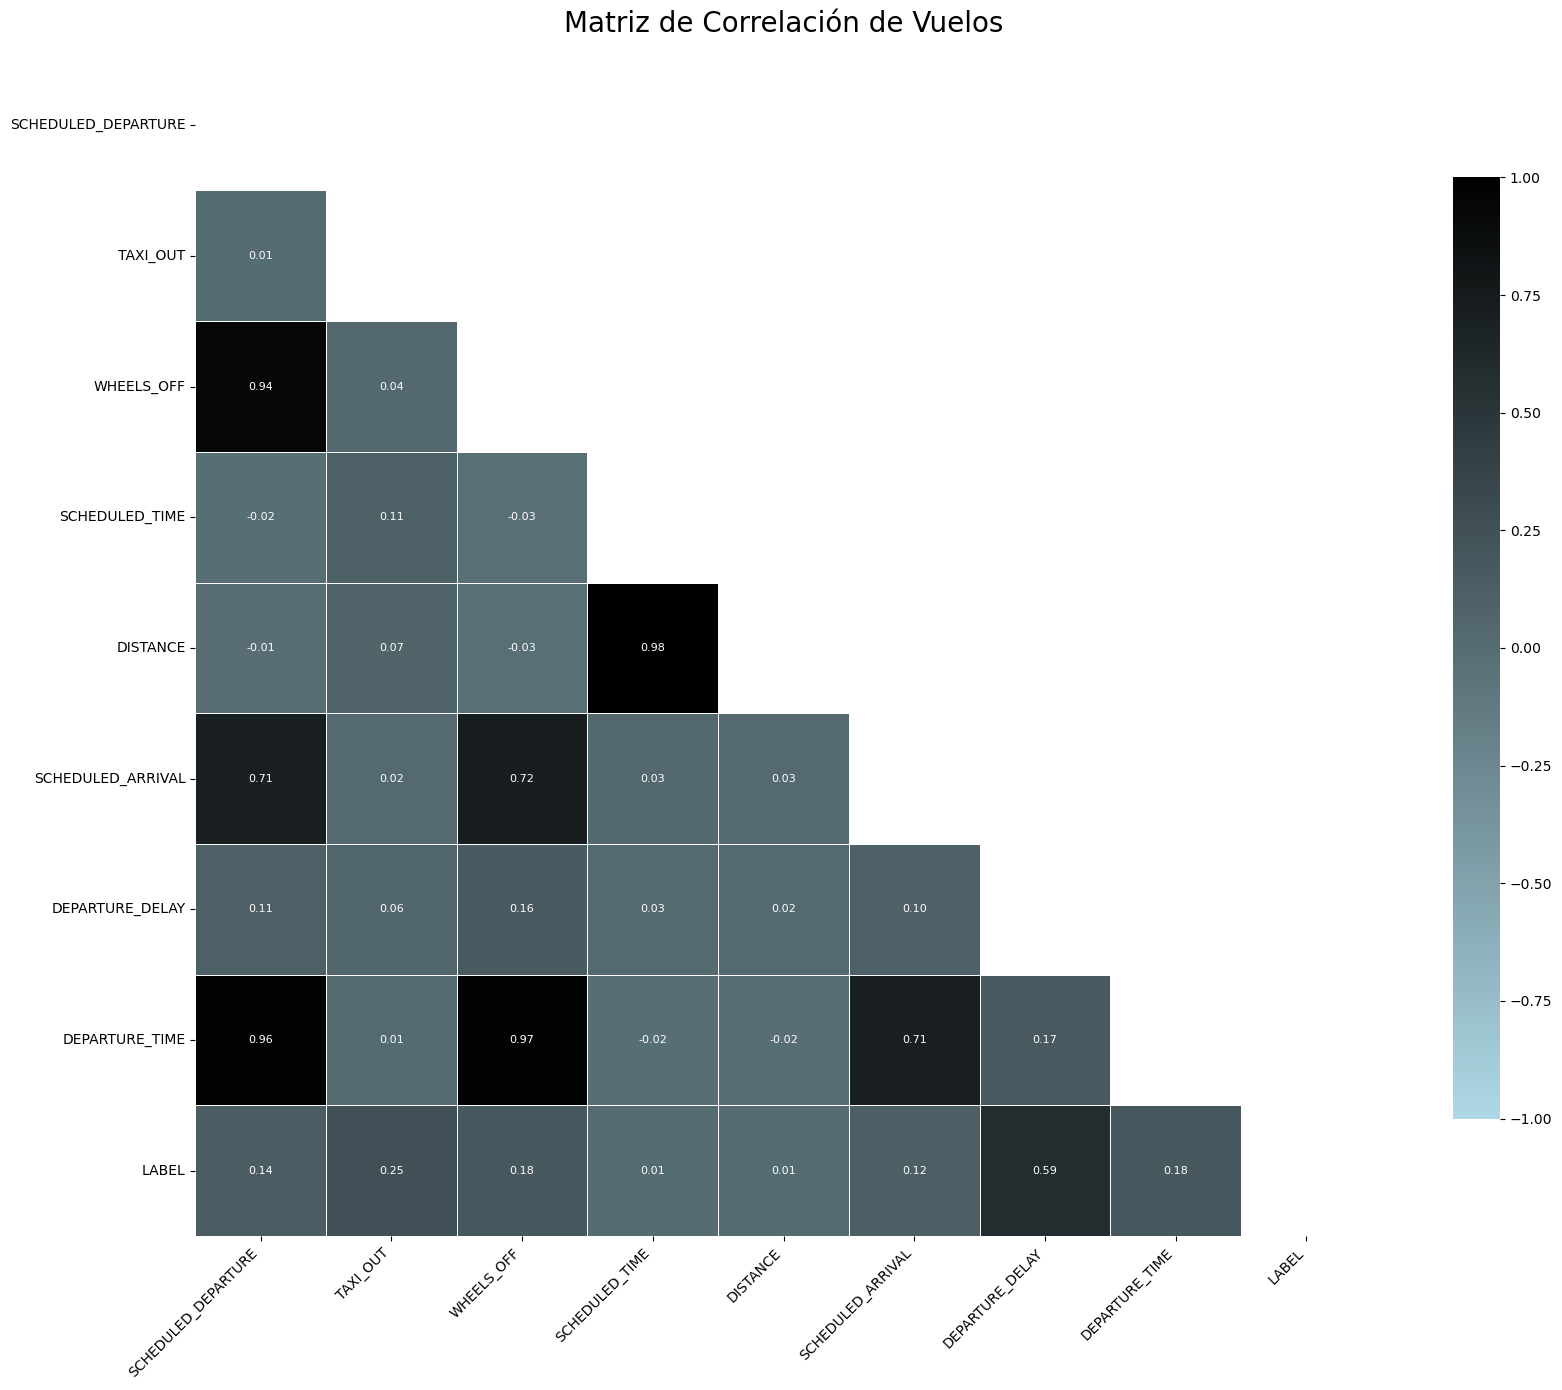

In [10]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# variables numéricas 
numeric_cols = [
    "SCHEDULED_DEPARTURE", "TAXI_OUT", "WHEELS_OFF", "SCHEDULED_TIME",
    "DISTANCE", "SCHEDULED_ARRIVAL", "DEPARTURE_DELAY", "DEPARTURE_TIME", "LABEL"
]

categorical_cols = ["AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"] 

# vector assembler
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_vector = assembler.transform(df_model).select("corr_features")

# matriz de Pearson
matrix = Correlation.corr(df_vector, "corr_features").collect()[0][0]
cor_np = matrix.toArray()
corr_matrix_df = pd.DataFrame(cor_np, columns=numeric_cols, index=numeric_cols)

# triángulo superior
mask = np.triu(np.ones_like(corr_matrix_df, dtype=bool))

plt.figure(figsize=(18, 14))
cmap = LinearSegmentedColormap.from_list("light_blue_to_black", ["#ADD8E6", "#000000"])
sns.heatmap(corr_matrix_df, 
            mask=mask, 
            cmap=cmap, 
            vmin=-1.0, vmax=1.0,      
            center=0,                  
            square=True,               
            linewidths=0.5,           
            cbar_kws={"shrink": 0.8},  
            annot=True,               
            fmt=".2f",                
            annot_kws={"size": 8})     

plt.title("Matriz de Correlación de Vuelos", fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')    
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Independientemente del escenario anterior, hay variables redundantes que dicen exactamente lo mismo. 

- El gemelo de la Distancia (0.98): DISTANCE y SCHEDULED_TIME son la misma variable disfrazada.

Nos quedamos con: DISTANCE (es un dato físico inmutable).

- El gemelo de los Horarios (>0.94): SCHEDULED_DEPARTURE, WHEELS_OFF y DEPARTURE_TIME están todas correlacionadas casi al 100%.

Nos quedamos con: SCHEDULED_DEPARTURE (es la métrica base y planificada).


## 3.5 Análisis de Correlación con LABEL - Variables Categóricas

Como las variables categóricas podrían tener muchas categorías como por ejemplo, TAIL_NUMBER, que es la matrícula del avión o FLIGHT_NUMBER, el número de vuelo, no podríamos resumir estas variables con categorías, procedemos a agrupar por cada cada variables categórico como ORIGIN_AIRPORT, y mirar que aeropuertos tienen significancia estadística en la variable respuesta.

In [11]:
impacto_aeropuerto = df_model.groupBy("ORIGIN_AIRPORT").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+--------------+----------+-------------------+
|ORIGIN_AIRPORT|NUM_VUELOS|       PROB_RETRASO|
+--------------+----------+-------------------+
|           PBG|       278| 0.3237410071942446|
|           MMH|       140|                0.3|
|           ASE|      3263|0.29665951578302174|
|           PPG|       106|0.29245283018867924|
|           OTH|       264| 0.2727272727272727|
|           UST|       144| 0.2638888888888889|
|           BPT|       905| 0.2596685082872928|
|         11695|       156| 0.2564102564102564|
|           MVY|       205|0.24878048780487805|
|           HPN|      7132|0.24733595064498037|
|           CEC|       173|0.24277456647398843|
|           RHI|       937|0.24119530416221985|
|           ORD|    276554| 0.2410487644366019|
|           LBE|      1245|0.24016064257028114|
|           LGA|     94834|0.23946053103317375|
|           TTN|      2771|0.23782028148682785|
|           EGE|      1198| 0.2353923205342237|
|         13795|       112|0.23214285714

In [12]:
impacto_aeropuerto = df_model.groupBy("DESTINATION_AIRPORT").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+-------------------+----------+-------------------+
|DESTINATION_AIRPORT|NUM_VUELOS|       PROB_RETRASO|
+-------------------+----------+-------------------+
|                PBG|       281| 0.3238434163701068|
|                ASE|      3260| 0.3156441717791411|
|                GUM|       331|  0.311178247734139|
|                OTH|       266| 0.3007518796992481|
|                BPT|       915|0.29617486338797816|
|                MQT|       296| 0.2939189189189189|
|                BQN|      1328| 0.2914156626506024|
|                TTN|      2761| 0.2817819630568635|
|                GUC|       470|0.27872340425531916|
|                PSE|       737|0.27408412483039346|
|                LGA|     94527| 0.2625599035196293|
|                LBE|      1247| 0.2590216519647153|
|                COU|      1256| 0.2571656050955414|
|                ACY|      3530|0.25127478753541077|
|                UST|       146| 0.2465753424657534|
|                IAG|       313|0.246006389776

In [13]:
impacto_aeropuerto = df_model.groupBy("AIRLINE_NAMES").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+--------------------+----------+-------------------+
|       AIRLINE_NAMES|NUM_VUELOS|       PROB_RETRASO|
+--------------------+----------+-------------------+
|    Spirit Air Lines|    115193| 0.2970753431198076|
|Frontier Airlines...|     90090|0.26162726162726163|
|     JetBlue Airways|    262042|0.22582257806000564|
|American Eagle Ai...|    278791|0.21717702508330614|
|United Air Lines ...|    507762| 0.2062422946183448|
|Atlantic Southeas...|    554752| 0.1968158744808491|
|      Virgin America|     61248| 0.1923001567398119|
|Southwest Airline...|   1242403| 0.1904583295436344|
|     US Airways Inc.|    194223|0.18818059653079192|
|Skywest Airlines ...|    576814|0.18687999944522846|
|American Airlines...|    712935|0.18273615406734134|
|Delta Air Lines Inc.|    870275|0.13561575364109046|
|Alaska Airlines Inc.|    171439|0.13037873529360297|
|Hawaiian Airlines...|     76041|0.11333359634933786|
+--------------------+----------+-------------------+



## 3.6 Selección de Variables para Modelado

In [14]:
df_model_reducido = df_model.select("MONTH", "DAY_OF_WEEK", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "SCHEDULED_DEPARTURE", "DISTANCE", "SCHEDULED_ARRIVAL", "LABEL")

# 4. Modelado
## 4.1 Modelo básico


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Separar en Train-Test
train = df_model_reducido.filter(df_model_reducido["MONTH"] <= 10)
test = df_model_reducido.filter(df_model_reducido["MONTH"] > 10)

# variables predictoras 
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL", 
]

# assembler
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)


lr = LogisticRegression(featuresCol="features", labelCol="LABEL")

print("Entrenando el modelo... (esto puede tardar unos segundos)")
modelo_lr = lr.fit(train_assembled)

# predicciones con los meses 11 y 12
predicciones = modelo_lr.transform(test_assembled)

# Usaremos el Área Bajo la Curva ROC - AUC
evaluator = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predicciones)

print(f"--- RESULTADOS DEL MODELO ---")
print(f"Área bajo la curva ROC (AUC): {auc:.4f}")

# (Opcional) Ver las predicciones frente a la realidad
predicciones.select("LABEL", "prediction", "probability").show(5)

Entrenando el modelo... (esto puede tardar unos segundos)


--- RESULTADOS DEL MODELO ---
Área bajo la curva ROC (AUC): 0.5845


+-----+----------+--------------------+
|LABEL|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.92798998106795...|
|    0|       0.0|[0.92426101832234...|
|    0|       0.0|[0.91990858007920...|
|    0|       0.0|[0.92364702248474...|
|    0|       0.0|[0.92601958974978...|
+-----+----------+--------------------+
only showing top 5 rows



## 4.2 RandomForest

In [16]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

train = df_model_reducido.filter(df_model_reducido["MONTH"] <= 10)
test = df_model_reducido.filter(df_model_reducido["MONTH"] > 10)

# variables predictoras 
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL",
    "MONTH"
]

# assembler
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")

train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# modelo
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10, 
    maxDepth=7, 
    maxBins=1000,         
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest... (esto puede tardar unos minutos)")
modelo_rf = rf.fit(train_assembled)

# predicciones con los meses 11 y 12
predicciones_rf = modelo_rf.transform(test_assembled)

# metricas
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest... (esto puede tardar unos minutos)


26/05/11 19:15:29 WARN MemoryStore: Not enough space to cache rdd_379_0 in memory! (computed 99.9 MiB so far)
26/05/11 19:15:29 WARN BlockManager: Persisting block rdd_379_0 to disk instead.
26/05/11 19:15:29 WARN MemoryStore: Not enough space to cache rdd_379_1 in memory! (computed 99.9 MiB so far)
26/05/11 19:15:29 WARN BlockManager: Persisting block rdd_379_1 to disk instead.
26/05/11 19:15:30 WARN MemoryStore: Not enough space to cache rdd_379_3 in memory! (computed 99.9 MiB so far)
26/05/11 19:15:30 WARN BlockManager: Persisting block rdd_379_3 to disk instead.
26/05/11 19:15:30 WARN MemoryStore: Not enough space to cache rdd_379_2 in memory! (computed 99.9 MiB so far)
26/05/11 19:15:30 WARN BlockManager: Persisting block rdd_379_2 to disk instead.
26/05/11 19:15:49 WARN MemoryStore: Not enough space to cache rdd_379_1 in memory! (computed 99.9 MiB so far)
26/05/11 19:15:49 WARN MemoryStore: Not enough space to cache rdd_379_1 in memory! (computed 2.3 MiB so far)
26/05/11 19:15:50

--- RESULTADOS RANDOM FOREST ---
Área bajo la curva ROC (AUC): 0.5855
Área bajo la curva PR (PR AUC): 0.2186

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|764741|
|    1|       0.0|167343|
+-----+----------+------+



Probamos a añadir las variables categóricas:

In [17]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# variables categóricas que queremos usar
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DAY_OF_WEEK"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

# StringIndexer
indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")

df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

# split
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# añadir categoricas
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL",
    "MONTH"
] + indexed_cols 

# assembler
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")

train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# 
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10, 
    maxDepth=7, 
    maxBins=1000,         
    cacheNodeIds=True,    
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest... (esto puede tardar unos minutos)")
modelo_rf = rf.fit(train_assembled)

# predicciones con los meses 11 y 12
predicciones_rf = modelo_rf.transform(test_assembled)

# metricas
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")


auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest... (esto puede tardar unos minutos)


26/05/11 19:20:10 WARN MemoryStore: Not enough space to cache rdd_592_1 in memory! (computed 96.4 MiB so far)
26/05/11 19:20:10 WARN BlockManager: Persisting block rdd_592_1 to disk instead.
26/05/11 19:20:11 WARN MemoryStore: Not enough space to cache rdd_592_3 in memory! (computed 96.4 MiB so far)
26/05/11 19:20:11 WARN BlockManager: Persisting block rdd_592_3 to disk instead.
26/05/11 19:20:12 WARN MemoryStore: Not enough space to cache rdd_592_2 in memory! (computed 96.4 MiB so far)
26/05/11 19:20:12 WARN BlockManager: Persisting block rdd_592_2 to disk instead.
26/05/11 19:20:37 WARN MemoryStore: Not enough space to cache rdd_592_2 in memory! (computed 40.7 MiB so far)
26/05/11 19:20:37 WARN MemoryStore: Not enough space to cache rdd_592_1 in memory! (computed 27.1 MiB so far)
26/05/11 19:20:37 WARN MemoryStore: Not enough space to cache rdd_592_2 in memory! (computed 5.2 MiB so far)
26/05/11 19:20:37 WARN MemoryStore: Not enough space to cache rdd_592_1 in memory! (computed 3.5 M

--- RESULTADOS RANDOM FOREST ---
Área bajo la curva ROC (AUC): 0.5765
Área bajo la curva PR (PR AUC): 0.2151

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|764741|
|    1|       0.0|167343|
+-----+----------+------+



El modelo sigue precidiendo todo sin retraso, puede ser debido al desbalanceo de clases. Como el 81% de los vuelos llegan a tiempo, el algoritmo de Random Forest ha descubierto que la forma más "fácil" de equivocarse poco es apostar siempre al 0. Si apuesta siempre al 0, acierta el 81% de las veces. Al algoritmo le parece un trato excelente, pero para tu caso de uso es inútil. Vamo a probar equilibrando las clases.
## 4.3 RandomForest con Desbalanceo


In [18]:
import pyspark.sql.functions as F
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# UNDERSAMPLING: EQUILIBRAR LOS DATOS (50% Retrasos / 50% Puntuales)

train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)
count_0 = train_0.count()
count_1 = train_1.count()

print(f"Antes del balanceo - Puntuales: {count_0}, Retrasados: {count_1}")

# porcentaje de la clase 0 necesario para igualar a la clase 1
fraccion = count_1 / count_0

# muestra aleatoria y unión
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

print(f"Después del balanceo - Entrenando con {train_balanced.count()} vuelos en total (50/50)\n")


# ENTRENAMIENTO DEL RANDOM FOREST
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10,          
    maxDepth=6,           
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest balanceado y optimizado en memoria...")
modelo_rf = rf.fit(train_balanced)


# PREDICCIÓN Y EVALUACIÓN
print("Haciendo predicciones en el set de test...")
predicciones_rf = modelo_rf.transform(test_assembled)

evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print("\n--- RESULTADOS RANDOM FOREST BALANCEADO ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Antes del balanceo - Puntuales: 3885828, Retrasados: 896096


Después del balanceo - Entrenando con 1793870 vuelos en total (50/50)

Entrenando Random Forest balanceado y optimizado en memoria...


Haciendo predicciones en el set de test...



--- RESULTADOS RANDOM FOREST BALANCEADO ---
Área bajo la curva ROC (AUC): 0.5771
Área bajo la curva PR (PR AUC): 0.2119

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|694755|
|    0|       1.0| 69986|
|    1|       0.0|148140|
|    1|       1.0| 19203|
+-----+----------+------+



Random Forest balanceado revela una capacidad predictiva global limitada. Un Área Bajo la Curva ROC (AUC) de 0.5771 y un PR AUC de 0.2119. 

Aunque la técnica de submuestreo (undersampling) logró corregir la polarización del modelo inicial —permitiendo identificar correctamente 19.203 casos de retraso (Verdaderos Positivos)—, el alto volumen de Falsos Negativos (148.140) indica que el modelo tiene dificultades para generalizar. Esta limitación no se debe a una falla algorítmica, sino a la naturaleza estática de las variables predictoras disponibles en este escenario de predicción temprana. 

Hay factores que no se están atendiendo que servirían para predecir de forma más precisa los retrasos, como las condiciones meteorológicas puntuales, la saturación del tráfico aéreo diario o el efecto dominó provocado por el retraso de la aeronave en rutas previas (late aircraft delay).


## 4.4 RandomForest - Añadir Variables con Poder Predictivo 
### Hora de Salida con el Horario Previsto de Salida y IS_WEEKEND con DAY_OF_THE_WEEK


In [19]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print("1. Creando nuevas variables predictoras (Feature Engineering)...")

# HORA exacta de salida y FIN DE SEMANA
df_features = df_model.withColumn("DEPARTURE_HOUR", (F.col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType()))
df_features = df_features.withColumn("IS_WEEKEND", F.when(F.col("DAY_OF_WEEK").isin([6, 7]), 1).otherwise(0))

df_model_reducido = df_features.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", 
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", 
    "AIRLINE_NAMES", "DISTANCE", "LABEL"
)

print("2. Indexando variables categóricas...")
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

print("3. Haciendo el split temporal y ensamblando...")
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

columnas_predictoras = [
    "DISTANCE", 
    "MONTH",
    "IS_WEEKEND",
    "DEPARTURE_HOUR"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

print("4. Aplicando Undersampling (50/50)...")
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

print("5. Entrenando Random Forest...")
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,  
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)
modelo_rf = rf.fit(train_balanced)

print("6. Evaluando el modelo...")
predicciones_rf = modelo_rf.transform(test_assembled)

evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print("\n" + "="*45)
print("--- RESULTADOS FINALES ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f} (El anterior era 0.5771)")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f} (El anterior era 0.2119)")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

1. Creando nuevas variables predictoras (Feature Engineering)...
2. Indexando variables categóricas...


3. Haciendo el split temporal y ensamblando...
4. Aplicando Undersampling (50/50)...


5. Entrenando Random Forest...


6. Evaluando el modelo...



--- RESULTADOS FINALES ---
Área bajo la curva ROC (AUC): 0.5971 (El anterior era 0.5771)
Área bajo la curva PR (PR AUC): 0.2349 (El anterior era 0.2119)

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|760944|
|    0|       1.0|  3797|
|    1|       0.0|165314|
|    1|       1.0|  2029|
+-----+----------+------+



La aplicación de Ingeniería de Variables (extracción de la franja horaria y factor de fin de semana) logró incrementar el poder predictivo global del modelo, elevando el AUC ROC a 0.5971. No obstante, al evaluar la matriz de confusión, se observa que el Random Forest adoptó un sesgo conservador. Redujo drásticamente la tasa de Falsos Positivos a costa de sacrificar la sensibilidad (Recall), identificando únicamente los retrasos con mayor certidumbre estadística. Este comportamiento confirma que, ante la ausencia de variables dinámicas operativas (clima, tráfico en tiempo real), los árboles de decisión priorizan la precisión sobre la exhaustividad en este conjunto de datos.

## 4.4 Random Forest - Mejora mediante la Integración de Datos Meteorológicos 

Hasta este punto, nuestro modelo predictivo ha dependido exclusivamente de variables logísticas estáticas, como la franja horaria, el día de la semana o la distancia del trayecto. Sin embargo, en la aviación comercial, las disrupciones operativas están intrínsecamente ligadas a las condiciones ambientales. Para dotar al algoritmo de este contexto y superar el límite predictivo actual, hemos decidido integrar información meteorológica histórica correspondiente al año 2015.

Para evitar la maldición de la dimensionalidad y no sobrecargar la memoria de nuestro clúster Spark, no utilizaremos todas las métricas climáticas disponibles, sino que hemos seleccionado los tres conjuntos de datos más críticos para la operativa aeroportuaria:

* **Velocidad del viento (`wind_speed.csv`):** Las rachas de viento cruzado limitan el uso de ciertas pistas, reduciendo la capacidad operativa de los aeropuertos y generando congestión en el espacio aéreo.
* **Temperatura (`temperature.csv`):** Las temperaturas extremas tienen un impacto directo. El calor extremo reduce la densidad del aire (limitando el peso al despegue), mientras que las temperaturas gélidas obligan a aplicar protocolos de *de-icing* (descongelación de alas), lo que añade demoras fijas muy significativas antes del despegue. Los datos originales vienen en grados Kelvin, por lo que aplicaremos una transformación a grados Celsius para facilitar su interpretabilidad.
* **Condiciones meteorológicas (`weather_description.csv`):** Este dataset contiene descripciones en formato de texto (como "light rain" o "thunderstorm"). Mediante expresiones regulares (RegEx), extraeremos las palabras clave que denotan peligro y transformaremos esta información en una variable binaria (`BAD_WEATHER`), la cual actuará como una bandera de riesgo para el modelo.


### 4.4.1 Unir los 3 CSVs (Temperature, Wind y DescriptionWeather)
#### Temperature - Pasar de Kelvin a Celsius y unir Ciudad con IATA Code
#### Wind - unir Ciudad con IATA Code
#### Weather - poner los valores de la tabla como variables (Mist, Few Clouds, sky is clear, scattered clouds, haze...), unir Ciudad con IATA Code y poner un 1 en la variable que tiene valor el resgistro






In [20]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

# Ciudad -> IATA -> Zona Horaria 
weather_mapping = [
    ("New York", "JFK", "America/New_York"), ("New York", "LGA", "America/New_York"), ("New York", "EWR", "America/New_York"),
    ("Boston", "BOS", "America/New_York"), ("Philadelphia", "PHL", "America/New_York"), 
    ("Atlanta", "ATL", "America/New_York"), ("Miami", "MIA", "America/New_York"), 
    ("Detroit", "DTW", "America/Detroit"),
    ("Chicago", "ORD", "America/Chicago"), ("Chicago", "MDW", "America/Chicago"), 
    ("Dallas", "DFW", "America/Chicago"), ("Dallas", "DAL", "America/Chicago"), 
    ("Houston", "IAH", "America/Chicago"), ("Houston", "HOU", "America/Chicago"),
    ("San Antonio", "SAT", "America/Chicago"),
    ("Denver", "DEN", "America/Denver"), ("Phoenix", "PHX", "America/Phoenix"),
    ("Los Angeles", "LAX", "America/Los_Angeles"), ("San Diego", "SAN", "America/Los_Angeles"), 
    ("Las Vegas", "LAS", "America/Los_Angeles")
]
df_mapping = spark.createDataFrame(weather_mapping, ["City", "IATA", "Timezone"])
ciudades_unicas = list(set([row[0] for row in weather_mapping]))


# reestructurar el dataset a formato largo (año 2015)
def unpivot_weather(df, value_col_name):
    df = df.withColumn("datetime", F.to_timestamp("datetime"))
    df_2015 = df.filter(F.year("datetime") == 2015)
    unpivot_expr = f"stack({len(ciudades_unicas)}, " + ", ".join([f"'{c}', `{c}`" for c in ciudades_unicas]) + f") as (City, {value_col_name})"
    return df_2015.select("datetime", F.expr(unpivot_expr))

# temperatura y viento se unen a descripcion
df_weather_full = unpivot_weather(df_wind, "Wind_Speed") \
    .join(unpivot_weather(df_temp, "Temperature_K"), ["datetime", "City"], "inner") \
    .join(unpivot_weather(df_desc, "Description"), ["datetime", "City"], "inner")

# Kelvin a Celsius
df_weather_full = df_weather_full.withColumn("Temperature_C", F.col("Temperature_K") - 273.15)
palabras_riesgo = "snow|storm|thunder|heavy|fog|mist|rain"
df_weather_full = df_weather_full.withColumn("BAD_WEATHER", F.when(F.lower(F.col("Description")).rlike(palabras_riesgo), 1).otherwise(0))

### 4.4.2 Ajuste de las Zonas Horarias. 2 ciudades tienen zonas horarias diferentes


Hemos resuelto dos problemas críticos de integración de datos para proteger la precisión del modelo:Sincronización horaria: 

- Ajustamos los datos meteorológicos (UTC) a la hora local de cada aeropuerto usando from_utc_timestamp en Spark, evitando desfases que invaliden la correlación entre clima y vuelos.

- Calidad sobre cantidad: Aplicamos un Inner Join para excluir aeropuertos sin sensores meteorológicos. Esto reduce el volumen de datos, pero elimina el "ruido" y garantiza que el modelo se entrene solo con información real y fiable de los grandes centros de conexión.

In [21]:
# asignar aeropuerto y a zona horaria
df_weather = df_weather_full.join(F.broadcast(df_mapping), "City", "inner")
df_weather = df_weather.withColumn("local_weather_datetime", F.from_utc_timestamp(F.col("datetime"), F.col("Timezone")))

df_weather = df_weather.select(
    F.col("local_weather_datetime").alias("weather_datetime"), 
    F.col("IATA").alias("WEATHER_IATA"), 
    F.col("Wind_Speed").cast("double"), 
    F.col("Temperature_C").cast("double"), 
    F.col("BAD_WEATHER").cast("integer")
).dropna()


df_model = df_model.withColumn("DEPARTURE_HOUR", (F.col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType()))
df_model = df_model.withColumn("IS_WEEKEND", F.when(F.col("DAY_OF_WEEK").isin([6, 7]), 1).otherwise(0))

# timestamp
df_model = df_model.withColumn("flight_datetime", F.to_timestamp(
    F.concat_ws("-", 
                F.col("YEAR"), 
                F.lpad(F.col("MONTH").cast("string"), 2, "0"), 
                F.lpad(F.col("DAY").cast("string"), 2, "0"), 
                F.lpad(F.col("DEPARTURE_HOUR").cast("string"), 2, "0")
               ), 
    "yyyy-MM-dd-HH"
))

# union
df_unified = df_model.join(
    df_weather,
    (df_model["ORIGIN_AIRPORT"] == df_weather["WEATHER_IATA"]) & (df_model["flight_datetime"] == df_weather["weather_datetime"]),
    "inner" 
)

df_model_reducido = df_unified.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DISTANCE", 
    "Wind_Speed", "Temperature_C", "BAD_WEATHER", "LABEL"
)

print(f"Total de registros de alta calidad para entrenar: {df_model_reducido.count():,}")

Total de registros de alta calidad para entrenar: 2,576,764


Con nuestro conjunto de datos purificado y enriquecido, iniciamos la canalización de *Machine Learning*. Primeramente, vectorizamos las variables categóricas. Posteriormente, dividimos el dataset aplicando una partición temporal (meses 1 a 10 para Entrenamiento y meses 11 a 12 para Prueba). Esta separación respeta el orden cronológico real, evitando que el modelo "vea el futuro" durante su fase de aprendizaje.

Por último, dado el desbalanceo natural entre vuelos puntuales y demorados, aplicamos una técnica de *Undersampling*, extrayendo una muestra aleatoria de la clase mayoritaria hasta lograr una proporción simétrica del 50/50. Esto impide que los algoritmos se acomoden en predecir sistemáticamente que ningún vuelo se retrasa.

In [22]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Indexación
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

# Split Temporal
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# Ensamblado de Vectores
columnas_predictoras = [
    "DISTANCE", "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR",
    "Wind_Speed", "Temperature_C", "BAD_WEATHER"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# Balanceo de Clases (Undersampling)
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

# Definición de Evaluadores globales
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")


Procederemos a evaluar el comportamiento de los datos climáticos a través de tres arquitecturas diferentes: un modelo lineal de referencia y dos algoritmos de ensamblado basados en árboles de decisión. (como se ha realizado anteriormente)

# 5. Modelado

## 5.1 Regresión Logística (Modelo Base)
Iniciamos la evaluación con un modelo lineal clásico. Su propósito principal es actuar como nuestra línea base (*baseline*), permitiéndonos observar si existe una relación matemática directa y proporcional entre el incremento de las variables climáticas (como la velocidad del viento) y la probabilidad de sufrir un retraso.

In [23]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="LABEL")
modelo_lr = lr.fit(train_balanced)
predicciones_lr = modelo_lr.transform(test_assembled)

print("="*45)
print("--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_lr):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_lr):.4f}")
print("="*45)

--- RESULTADOS REGRESIÓN LOGÍSTICA ---


Área bajo la curva ROC (AUC): 0.6190


Área bajo la curva PR (PR AUC): 0.2727


## 5.2 Random Forest Classifier
Este algoritmo implementa un enfoque de entrenamiento en paralelo (*Bagging*). Al contar ahora con variables climáticas depuradas, esperamos que las múltiples ramas de los árboles de decisión sean capaces de identificar umbrales críticos (por ejemplo, temperaturas inferiores a cero grados en aeropuertos específicos) que desencadenan cuellos de botella en la operativa logística.

In [24]:
from pyspark.ml.classification import RandomForestClassifier

spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest balanceado...")
modelo_rf = rf.fit(train_balanced)
predicciones_rf = modelo_rf.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_rf):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_rf):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest balanceado...



--- RESULTADOS RANDOM FOREST ---


Área bajo la curva ROC (AUC): 0.6304


Área bajo la curva PR (PR AUC): 0.2856

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|332173|
|    0|       1.0| 35773|
|    1|       0.0| 67127|
|    1|       1.0| 18970|
+-----+----------+------+



## 5.3 Árboles Potenciados por Gradiente (Gradient-Boosted Trees)
A diferencia del paralelismo del Random Forest, el GBT utiliza una arquitectura de *Boosting*, entrenando los árboles de manera secuencial. Cada nuevo árbol dedica sus recursos a corregir exclusivamente los errores cometidos por la iteración anterior. Confiamos en que este modelo sea el más apto para modelar las interacciones complejas y no lineales, extrayendo el máximo rendimiento a la combinación de congestión aeroportuaria y disrupción ambiental.

In [25]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Gradient-Boosted Trees...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia de Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f"{name}: {imp:.4f}")

Entrenando Gradient-Boosted Trees...


26/05/11 19:47:21 WARN BlockManager: Asked to remove block rdd_2191_2, which does not exist
26/05/11 19:47:21 WARN BlockManager: Asked to remove block rdd_2191_1, which does not exist
26/05/11 19:47:53 WARN BlockManager: Asked to remove block rdd_2405_0, which does not exist
26/05/11 19:48:00 WARN BlockManager: Asked to remove block rdd_2449_1, which does not exist
26/05/11 19:48:18 WARN BlockManager: Asked to remove block rdd_2588_0, which does not exist
26/05/11 19:48:18 WARN BlockManager: Asked to remove block rdd_2588_3, which does not exist
26/05/11 19:48:18 WARN BlockManager: Asked to remove block rdd_2588_2, which does not exist
26/05/11 19:48:18 WARN BlockManager: Asked to remove block rdd_2582_0, which does not exist
26/05/11 19:48:18 WARN BlockManager: Asked to remove block rdd_2582_2, which does not exist



--- RESULTADOS FINALES GBT ---


26/05/11 19:49:28 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva ROC (AUC): 0.6367


26/05/11 19:49:55 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva PR (PR AUC): 0.2914

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 19:50:24 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|320984|
|    0|       1.0| 46962|
|    1|       0.0| 63098|
|    1|       1.0| 22999|
+-----+----------+------+


Importancia de Variables (Feature Importance):
DISTANCE: 0.0058
MONTH: 0.1234
IS_WEEKEND: 0.0241
DEPARTURE_HOUR: 0.1159
Wind_Speed: 0.0314
Temperature_C: 0.1000
BAD_WEATHER: 0.0637
ORIGIN_AIRPORT_INDEX: 0.1467
DESTINATION_AIRPORT_INDEX: 0.2808
AIRLINE_NAMES_INDEX: 0.1082


26/05/11 19:50:29 WARN DAGScheduler: Broadcasting large task binary with size 1099.5 KiB


## 5.4 GBTClassifier

In [26]:
from pyspark.ml.classification import GBTClassifier

spark.catalog.clearCache()

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Árboles Potenciados por Gradiente (GBT)...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia Predictiva de las Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f" - {name}: {imp:.4f}")

Entrenando Árboles Potenciados por Gradiente (GBT)...



--- RESULTADOS FINALES GBT ---


26/05/11 19:54:00 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva ROC (AUC): 0.6367


26/05/11 19:54:54 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva PR (PR AUC): 0.2914

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 19:55:46 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|320984|
|    0|       1.0| 46962|
|    1|       0.0| 63098|
|    1|       1.0| 22999|
+-----+----------+------+


Importancia Predictiva de las Variables (Feature Importance):
 - DISTANCE: 0.0058
 - MONTH: 0.1234
 - IS_WEEKEND: 0.0241
 - DEPARTURE_HOUR: 0.1159
 - Wind_Speed: 0.0314
 - Temperature_C: 0.1000
 - BAD_WEATHER: 0.0637
 - ORIGIN_AIRPORT_INDEX: 0.1467
 - DESTINATION_AIRPORT_INDEX: 0.2808
 - AIRLINE_NAMES_INDEX: 0.1082


26/05/11 19:55:53 WARN DAGScheduler: Broadcasting large task binary with size 1099.5 KiB


# 6. Mejora mediante la obtención de una nueva variable "PREVIOUS_FLIGHT_DELAYED"

Tras haber integrado con éxito el contexto medioambiental (corrigiendo las zonas horarias para asegurar la sincronía de los eventos meteorológicos), abordamos ahora la principal causa estructural de las disrupciones en la aviación comercial: el arrastre de demoras o *Efecto Dominó*. En la logística aeroportuaria, si un avión sufre un retraso en su ruta matutina, es altamente probable que traslade esa demora a todos sus vuelos posteriores durante ese mismo día, independientemente del clima en sus siguientes destinos.

Para que el modelo pueda capturar esta dinámica operativa sin cometer "Fuga de Datos" (*Data Leakage*), no podemos utilizar variables que se calculen a posteriori (como los minutos de retraso a la llegada). En su lugar, utilizaremos la matrícula física de la aeronave (`TAIL_NUMBER`). Mediante el uso de funciones de ventana (*Window Functions*) en Spark, ordenaremos cronológicamente todos los vuelos realizados por cada avión. A partir de ahí, extraeremos el estado operativo de su vuelo inmediatamente anterior. Si el avión ya venía con retraso de su destino previo, activaremos una bandera de riesgo (`PREVIOUS_FLIGHT_DELAYED`).

In [27]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

df_tracking = df_unified.filter(F.col("TAIL_NUMBER").isNotNull())

# Agrupamos por Avión y ordenamos por la fecha/hora del vuelo
window_tail = Window.partitionBy("TAIL_NUMBER").orderBy("flight_datetime")

# etiqueta del vuelo
df_tracking = df_tracking.withColumn(
    "PREVIOUS_FLIGHT_DELAYED", 
    F.lag("LABEL", 1).over(window_tail)
)

# asumir que el vuelo 0 sale bien
df_tracking = df_tracking.fillna({"PREVIOUS_FLIGHT_DELAYED": 0})

# dataset final
df_final = df_tracking.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DISTANCE", 
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",  # Bloque Climático
    "PREVIOUS_FLIGHT_DELAYED",                     # Bloque Operativo
    "LABEL"
)



## 6.1 Probar la nueva variable de VueloAnterior con BinaryClassificationEvaluator
Con nuestro conjunto de datos enriquecido en su máxima expresión, procedemos a la fase de preparación para el modelado predictivo. En primer lugar, los algoritmos de la biblioteca MLlib requieren que las variables categóricas (como la aerolínea o los aeropuertos) se transformen a un formato numérico, tarea que delegamos en un `StringIndexer`. Posteriormente, unificamos todas las características en un vector denso mediante `VectorAssembler`.

Es fundamental garantizar que la evaluación simule un entorno real. Por ello, aplicamos una partición estrictamente cronológica: utilizamos los diez primeros meses para el entrenamiento y reservamos noviembre y diciembre para validación.

Finalmente, para abordar el severo desbalanceo estructural del dataset, aplicamos una técnica de *Undersampling*. Extraemos una submuestra aleatoria de la clase mayoritaria (vuelos puntuales) hasta igualarla con la minoritaria. Esta estrategia fuerza a los algoritmos a prestar atención matemática a los retrasos, evitando un sesgo conservador.

In [28]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Transformación
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_final).transform(df_final)

# train-test
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# assembler
columnas_predictoras = [
    "DISTANCE", "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR",
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",
    "PREVIOUS_FLIGHT_DELAYED"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# Undersampling
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

## 6.2 Probar la nueva variable de VueloAnterior con LogisticRegression
Para cuantificar el impacto del *Feature Engineering* realizado, evaluaremos tres arquitecturas algorítmicas diferentes. El objetivo es comprobar qué modelo logra capitalizar mejor la sinergia entre el clima adverso y el estado de la aeronave.

In [29]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="LABEL")
modelo_lr = lr.fit(train_balanced)
predicciones_lr = modelo_lr.transform(test_assembled)

print("="*45)
print("--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_lr):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_lr):.4f}")
print("="*45)

--- RESULTADOS REGRESIÓN LOGÍSTICA ---


Área bajo la curva ROC (AUC): 0.6835


Área bajo la curva PR (PR AUC): 0.3752


## 6.3 Probar la nueva variable de VueloAnterior con RandomForest

In [30]:
from pyspark.ml.classification import RandomForestClassifier

spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Bosque Aleatorio balanceado...")
modelo_rf = rf.fit(train_balanced)
predicciones_rf = modelo_rf.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_rf):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_rf):.4f}")
print("="*45)

Entrenando Bosque Aleatorio balanceado...



--- RESULTADOS RANDOM FOREST ---


Área bajo la curva ROC (AUC): 0.6920


Área bajo la curva PR (PR AUC): 0.3899


## 6.4 Probar la nueva variable de VueloAnterior con GBTClassifier

In [33]:
from pyspark.ml.classification import GBTClassifier

spark.catalog.clearCache()

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Árboles Potenciados por Gradiente (GBT)...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia Predictiva de las Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f" - {name}: {imp:.4f}")

Entrenando Árboles Potenciados por Gradiente (GBT)...



--- RESULTADOS FINALES GBT ---


26/05/11 20:24:45 WARN DAGScheduler: Broadcasting large task binary with size 1132.4 KiB


Área bajo la curva ROC (AUC): 0.7025


26/05/11 20:25:48 WARN DAGScheduler: Broadcasting large task binary with size 1132.4 KiB


Área bajo la curva PR (PR AUC): 0.3959

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 20:26:49 WARN DAGScheduler: Broadcasting large task binary with size 1143.4 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|312577|
|    0|       1.0| 55369|
|    1|       0.0| 48370|
|    1|       1.0| 37727|
+-----+----------+------+


Importancia Predictiva de las Variables (Feature Importance):
 - DISTANCE: 0.0057
 - MONTH: 0.0980
 - IS_WEEKEND: 0.0179
 - DEPARTURE_HOUR: 0.1144
 - Wind_Speed: 0.0269
 - Temperature_C: 0.0882
 - BAD_WEATHER: 0.0451
 - PREVIOUS_FLIGHT_DELAYED: 0.1318
 - ORIGIN_AIRPORT_INDEX: 0.1291
 - DESTINATION_AIRPORT_INDEX: 0.2662
 - AIRLINE_NAMES_INDEX: 0.0766


26/05/11 20:27:00 WARN DAGScheduler: Broadcasting large task binary with size 1124.3 KiB


# 7. Mejoras y Visualizaciones

## 7.1 Nueva variable: Aeroopuertos Congestionados con Retrasos

Definir la nueva variable

In [34]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# umbral 20% de retrasos en la hora previa
X_THRESHOLD = 0.20

# Agrupamos por Aeropuerto y Fecha, y ordenamos por Hora.
window_airport = Window.partitionBy("ORIGIN_AIRPORT", "MONTH", "DAY") \
                       .orderBy("DEPARTURE_HOUR") \
                       .rangeBetween(-1, -1)

# Calcular la tasa de retrasos de la hora anterior
df_tracking = df_tracking.withColumn(
    "PREV_HOUR_DELAY_RATE",
    F.avg("LABEL").over(window_airport)
)

# Crear la variable binaria AIRPORT_CONGESTED
df_tracking = df_tracking.withColumn(
    "AIRPORT_CONGESTED", 
    F.when(F.col("PREV_HOUR_DELAY_RATE") >= X_THRESHOLD, 1).otherwise(0)
)

# Si a la hora anterior no hubo NINGÚN vuelo (ej: a las 04:00 AM), el rate será nulo. 
df_tracking = df_tracking.fillna({"AIRPORT_CONGESTED": 0})

# Borramos la columna auxiliar para no ensuciar el dataset
df_tracking = df_tracking.drop("PREV_HOUR_DELAY_RATE")

# dataset final añadiendo la nueva variable
df_final = df_tracking.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DISTANCE", 
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",  
    "PREVIOUS_FLIGHT_DELAYED",                     
    "AIRPORT_CONGESTED",                    
    "LABEL"
)

print("Muestra de vuelos en aeropuertos congestionados:")
df_final.filter(F.col("AIRPORT_CONGESTED") == 1).show(5)


Muestra de vuelos en aeropuertos congestionados:


+-----+----------+--------------+--------------+-------------------+--------------------+--------+----------+------------------+-----------+-----------------------+-----------------+-----+
|MONTH|IS_WEEKEND|DEPARTURE_HOUR|ORIGIN_AIRPORT|DESTINATION_AIRPORT|       AIRLINE_NAMES|DISTANCE|Wind_Speed|     Temperature_C|BAD_WEATHER|PREVIOUS_FLIGHT_DELAYED|AIRPORT_CONGESTED|LABEL|
+-----+----------+--------------+--------------+-------------------+--------------------+--------+----------+------------------+-----------+-----------------------+-----------------+-----+
|    1|         0|             8|           ATL|                DFW|American Airlines...|     731|       2.0|-1.464999999999975|          0|                      0|                1|    0|
|    1|         0|             8|           ATL|                OKC|Atlantic Southeas...|     761|       2.0|-1.464999999999975|          0|                      0|                1|    0|
|    1|         0|             8|           ATL|       

Definir los elementos del modelo para comprobar si la nueva variable consigue mejor rendimiento

In [35]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pyspark.sql.functions as F

# Transformación de variables categóricas a numéricas
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_final).transform(df_final)

# División temporal (Train/Test Split cronológico)
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# Ensamblado del vector de características predictoras
columnas_predictoras = [
    "DISTANCE", "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR",
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",
    "PREVIOUS_FLIGHT_DELAYED",     # Vuelo anterior del mismo avión
    "AIRPORT_CONGESTED"      # <--- NUEVA VARIABLE: Congestión del aeropuerto
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# Aplicación de Undersampling (Balanceo 50/50)
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

# Inicialización de evaluadores
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

Entrenar

In [36]:
from pyspark.ml.classification import GBTClassifier

spark.catalog.clearCache()

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Árboles Potenciados por Gradiente (GBT)...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia Predictiva de las Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f" - {name}: {imp:.4f}")

Entrenando Árboles Potenciados por Gradiente (GBT)...



--- RESULTADOS FINALES GBT ---


26/05/11 20:40:46 WARN DAGScheduler: Broadcasting large task binary with size 1145.9 KiB


Área bajo la curva ROC (AUC): 0.7395


26/05/11 20:41:21 WARN DAGScheduler: Broadcasting large task binary with size 1145.9 KiB


Área bajo la curva PR (PR AUC): 0.4410

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 20:42:15 WARN DAGScheduler: Broadcasting large task binary with size 1156.4 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|307379|
|    0|       1.0| 60567|
|    1|       0.0| 42402|
|    1|       1.0| 43695|
+-----+----------+------+


Importancia Predictiva de las Variables (Feature Importance):
 - DISTANCE: 0.0160
 - MONTH: 0.0537
 - IS_WEEKEND: 0.0077
 - DEPARTURE_HOUR: 0.0798
 - Wind_Speed: 0.0135
 - Temperature_C: 0.0511
 - BAD_WEATHER: 0.0362
 - PREVIOUS_FLIGHT_DELAYED: 0.1184
 - AIRPORT_CONGESTED: 0.1849
 - ORIGIN_AIRPORT_INDEX: 0.1030
 - DESTINATION_AIRPORT_INDEX: 0.2555
 - AIRLINE_NAMES_INDEX: 0.0802


26/05/11 20:42:25 WARN DAGScheduler: Broadcasting large task binary with size 1137.0 KiB


## 7.2  VALIDACIÓN CRUZADA

In [37]:
train_balanced.head(5)

[Row(MONTH=1, IS_WEEKEND=0, DEPARTURE_HOUR=6, ORIGIN_AIRPORT='ATL', DESTINATION_AIRPORT='TTN', AIRLINE_NAMES='Frontier Airlines Inc.', DISTANCE=701, Wind_Speed=1.0, Temperature_C=-2.0720000000000027, BAD_WEATHER=0, PREVIOUS_FLIGHT_DELAYED=0, AIRPORT_CONGESTED=0, LABEL=1, ORIGIN_AIRPORT_INDEX=0.0, DESTINATION_AIRPORT_INDEX=217.0, AIRLINE_NAMES_INDEX=10.0, features=DenseVector([701.0, 1.0, 0.0, 6.0, 1.0, -2.072, 0.0, 0.0, 0.0, 0.0, 217.0, 10.0])),
 Row(MONTH=1, IS_WEEKEND=0, DEPARTURE_HOUR=7, ORIGIN_AIRPORT='ATL', DESTINATION_AIRPORT='FLL', AIRLINE_NAMES='Spirit Air Lines', DISTANCE=581, Wind_Speed=1.0, Temperature_C=0.8770000000000095, BAD_WEATHER=0, PREVIOUS_FLIGHT_DELAYED=0, AIRPORT_CONGESTED=1, LABEL=1, ORIGIN_AIRPORT_INDEX=0.0, DESTINATION_AIRPORT_INDEX=16.0, AIRLINE_NAMES_INDEX=9.0, features=DenseVector([581.0, 1.0, 0.0, 7.0, 1.0, 0.877, 0.0, 0.0, 1.0, 0.0, 16.0, 9.0])),
 Row(MONTH=1, IS_WEEKEND=0, DEPARTURE_HOUR=7, ORIGIN_AIRPORT='ATL', DESTINATION_AIRPORT='LGA', AIRLINE_NAMES='De

In [38]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

print("--- 3.1. Ajuste de Hiperparámetros Eficiente (TrainValidationSplit con GBT) ---")

# CRÍTICO PARA NO SATURAR LA RAM: Configurar directorio de checkpoints
# Spark guardará el estado en disco temporalmente para vaciar la memoria.
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")
gbt.setCheckpointInterval(10)

# Malla reducida: profundidades más conservadoras para cuidar la memoria
paramGrid_gbt = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .addGrid(gbt.maxIter, [10, 20]) \
    .addGrid(gbt.stepSize, [0.1]) \
    .build()

# Sustituimos CrossValidator por TrainValidationSplit
tvs_gbt = TrainValidationSplit(
    estimator=gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator_roc, # Asume que tu evaluador ya está instanciado
    trainRatio=0.8,          # 80% entrenamiento, 20% validación
    seed=42
)

print(f"Ejecutando TrainValidationSplit sobre GBT con {len(paramGrid_gbt)} combinaciones...")
print("(Al usar TVS y Checkpoints, el riesgo de OutOfMemory se reduce drásticamente)")

cv_model_gbt = tvs_gbt.fit(train_balanced)
mejor_modelo_gbt = cv_model_gbt.bestModel
predicciones_cv_gbt = mejor_modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS OPTIMIZACIÓN GBT ---")
print(f"Mejor AUC conseguido: {evaluator_roc.evaluate(predicciones_cv_gbt):.4f}")
print(f"Mejor parámetro 'maxDepth': {mejor_modelo_gbt.getMaxDepth()}")
print(f"Mejor parámetro 'maxIter': {mejor_modelo_gbt.getMaxIter()}")
print(f"Mejor parámetro 'stepSize': {mejor_modelo_gbt.getStepSize()}")
print("="*45)

--- 3.1. Ajuste de Hiperparámetros Eficiente (TrainValidationSplit con GBT) ---
Ejecutando TrainValidationSplit sobre GBT con 4 combinaciones...
(Al usar TVS y Checkpoints, el riesgo de OutOfMemory se reduce drásticamente)



--- RESULTADOS OPTIMIZACIÓN GBT ---


Mejor AUC conseguido: 0.7414
Mejor parámetro 'maxDepth': 5
Mejor parámetro 'maxIter': 20
Mejor parámetro 'stepSize': 0.1


In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

print("--- 3.2. Ajuste de Hiperparámetros Eficiente (TrainValidationSplit con RandomForest) ---")

# Malla de parámetros ajustada
paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [5, 7]) \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.featureSubsetStrategy, ["auto"]) \
    .build()

# Usamos también TrainValidationSplit para ser consistentes con el ahorro de RAM
tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_roc,
    trainRatio=0.8,
    seed=42
)

print(f"Ejecutando TrainValidationSplit sobre Random Forest con {len(paramGrid_rf)} combinaciones...")

cv_model_rf = tvs_rf.fit(train_balanced)
mejor_modelo_rf = cv_model_rf.bestModel
predicciones_cv_rf = mejor_modelo_rf.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS OPTIMIZACIÓN RANDOM FOREST ---")
print(f"Mejor AUC conseguido: {evaluator_roc.evaluate(predicciones_cv_rf):.4f}")
print(f"Mejor parámetro 'maxDepth': {mejor_modelo_rf.getMaxDepth()}")
print(f"Mejor parámetro 'numTrees': {mejor_modelo_rf.getNumTrees}")
print(f"Mejor parámetro 'featureSubsetStrategy': {mejor_modelo_rf.getFeatureSubsetStrategy()}")
print("="*45)

--- 3.2. Ajuste de Hiperparámetros Eficiente (TrainValidationSplit con RandomForest) ---
Ejecutando TrainValidationSplit sobre Random Forest con 4 combinaciones...


26/05/12 01:50:54 WARN DAGScheduler: Broadcasting large task binary with size 1208.1 KiB
26/05/12 01:52:14 WARN DAGScheduler: Broadcasting large task binary with size 1541.5 KiB



--- RESULTADOS OPTIMIZACIÓN RANDOM FOREST ---


Mejor AUC conseguido: 0.7352
Mejor parámetro 'maxDepth': 7


TypeError: 'int' object is not callable

el error da igual porque se muestra el mejor de parámetro de numTrees y de featureSubsetStrategy en la siguiente celda

## 7.3 Speed Up, Size-Up

- Size-Up (Escalabilidad de Datos)

Concepto: Mantener el hardware fijo y aumentar progresivamente el volumen de datos (25%, 50%, 75%, 100%).

Objetivo: Comprobar que el sistema es robusto y puede absorber más información sin saturar la memoria RAM.

Comportamiento ideal: El tiempo de ejecución crece de forma estrictamente lineal o proporcional.

- Speed-Up (Escalabilidad de Hardware)

Concepto: Mantener los datos fijos (100%) y aumentar progresivamente los recursos computacionales (1, 2, 4, 8 procesadores/nodos).

Objetivo: Evaluar si el algoritmo aprovecha la paralelización de Spark para ser más rápido.

Comportamiento ideal: El tiempo de ejecución disminuye a la mitad al duplicar los recursos. (Advierte de que los algoritmos secuenciales no logran esto debido al coste de comunicación entre nodos o overhead).

In [41]:
import time
import pandas as pd
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier

print("1. Forzando a Spark a calcular y guardar todo el dataset en la memoria RAM...")
train_balanced.cache()
total_rows = train_balanced.count() 
print(f"Dataset base en memoria con {total_rows} filas listas.")

# Extraemos los mejores hiperparámetros obtenidos en las celdas anteriores
best_rf_depth = mejor_modelo_rf.getMaxDepth()
best_rf_trees = mejor_modelo_rf.getNumTrees

best_gbt_depth = mejor_modelo_gbt.getMaxDepth()
best_gbt_iter = mejor_modelo_gbt.getMaxIter()
best_gbt_step = mejor_modelo_gbt.getStepSize()

print(f"\nUsando parámetros óptimos -> RF: (Trees={best_rf_trees}, Depth={best_rf_depth}) | GBT: (Iter={best_gbt_iter}, Depth={best_gbt_depth})")

print("\n2. Iniciando pruebas de escalabilidad (Size-up) COMPARATIVAS...")
fracciones = [0.25, 0.50, 0.75, 1.0]
tiempos_rf = []
tiempos_gbt = []
volumenes = []

for frac in fracciones:
    df_sample = train_balanced.sample(withReplacement=False, fraction=frac, seed=42)
    
    # Materializamos la muestra ANTES del reloj
    df_sample.cache()
    volumen_muestra = df_sample.count() 
    volumenes.append(volumen_muestra)
    print(f"\n--- Evaluando fracción {frac*100}% (Volumen: {volumen_muestra} filas) ---")
    
    # ==========================================
    # PRUEBA A: RANDOM FOREST OPTIMIZADO
    # ==========================================
    start_time_rf = time.time()
    
    rf_sizeup = RandomForestClassifier(
        featuresCol="features", labelCol="LABEL", 
        numTrees=best_rf_trees, maxDepth=best_rf_depth, 
        maxBins=700, seed=42
    )
    rf_sizeup.fit(df_sample)
    
    tiempo_total_rf = time.time() - start_time_rf
    tiempos_rf.append(tiempo_total_rf)
    print(f"  -> Random Forest terminó en: {tiempo_total_rf:.2f} segundos.")
    
    # ==========================================
    # PRUEBA B: GRADIENT-BOOSTED TREES OPTIMIZADO
    # ==========================================
    start_time_gbt = time.time()
    
    gbt_sizeup = GBTClassifier(
        featuresCol="features", labelCol="LABEL", 
        maxIter=best_gbt_iter, maxDepth=best_gbt_depth, stepSize=best_gbt_step,
        checkpointInterval=10, # Mantenemos el checkpoint aquí también
        maxBins=700, seed=42
    )
    gbt_sizeup.fit(df_sample)
    
    tiempo_total_gbt = time.time() - start_time_gbt
    tiempos_gbt.append(tiempo_total_gbt)
    print(f"  -> Gradient-Boosted Trees terminó en: {tiempo_total_gbt:.2f} segundos.")
    
    # Liberamos la memoria de esta muestra para la siguiente vuelta
    df_sample.unpersist()

# 3. Mostrar los resultados
df_resultados_sizeup = pd.DataFrame({
    'Porcentaje_Datos': ['25%', '50%', '75%', '100%'],
    'Volumen_Filas': volumenes,
    'Tiempo_RF_Segundos': tiempos_rf,
    'Tiempo_GBT_Segundos': tiempos_gbt
})

print("\n" + "="*50)
print("=== TABLA DE RESULTADOS SIZE-UP COMPARATIVA ===")
print("="*50)
print(df_resultados_sizeup)




1. Forzando a Spark a calcular y guardar todo el dataset en la memoria RAM...


26/05/12 07:12:58 WARN CacheManager: Asked to cache already cached data.


Dataset base en memoria con 898779 filas listas.

Usando parámetros óptimos -> RF: (Trees=20, Depth=7) | GBT: (Iter=20, Depth=5)

2. Iniciando pruebas de escalabilidad (Size-up) COMPARATIVAS...



--- Evaluando fracción 25.0% (Volumen: 225714 filas) ---


  -> Random Forest terminó en: 129.61 segundos.


...

  -> Random Forest terminó en: 119.48 segundos.


  -> Gradient-Boosted Trees terminó en: 412.28 segundos.



--- Evaluando fracción 100.0% (Volumen: 898779 filas) ---


  -> Random Forest terminó en: 125.57 segundos.


  -> Gradient-Boosted Trees terminó en: 426.37 segundos.

=== TABLA DE RESULTADOS SIZE-UP COMPARATIVA ===
  Porcentaje_Datos  Volumen_Filas  Tiempo_RF_Segundos  Tiempo_GBT_Segundos
0              25%         225714          129.605384           396.342373
1              50%         449632          108.944177           385.922898
2              75%         674362          119.477521           412.284232
3             100%         898779          125.565856           426.369106


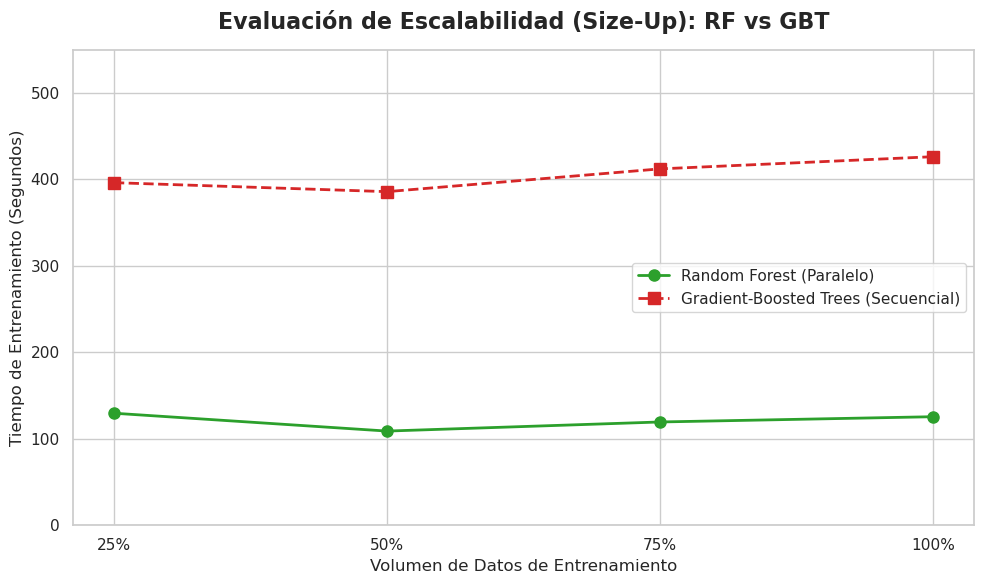

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Dibujar las dos líneas
plt.plot(df_resultados_sizeup['Porcentaje_Datos'], df_resultados_sizeup['Tiempo_RF_Segundos'], 
         marker='o', linestyle='-', linewidth=2, color='#2ca02c', label='Random Forest (Paralelo)', markersize=8)

plt.plot(df_resultados_sizeup['Porcentaje_Datos'], df_resultados_sizeup['Tiempo_GBT_Segundos'], 
         marker='s', linestyle='--', linewidth=2, color='#d62728', label='Gradient-Boosted Trees (Secuencial)', markersize=8)

# Títulos y etiquetas
plt.title('Evaluación de Escalabilidad (Size-Up): RF vs GBT', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Volumen de Datos de Entrenamiento', fontsize=12)
plt.ylabel('Tiempo de Entrenamiento (Segundos)', fontsize=12)

# Ajuste del eje Y para que empiece en 0
plt.ylim(0, 550)

# Leyenda y marcas
plt.legend(fontsize=11, loc='center right')
plt.tight_layout()

# Mostrar el gráfico (Guárdalo haciendo click derecho sobre él)
plt.show()

## Speed Up - Aproximación 

Analizamos la velocidad usando una aproximación del Speed-Up. Random Forest escala muy bien y reduce tiempos drásticamente con más núcleos. En cambio, Gradient-Boosted Trees apenas mejora aunque subas los núcleos, porque su estructura secuencial impide aprovechar la potencia extra.

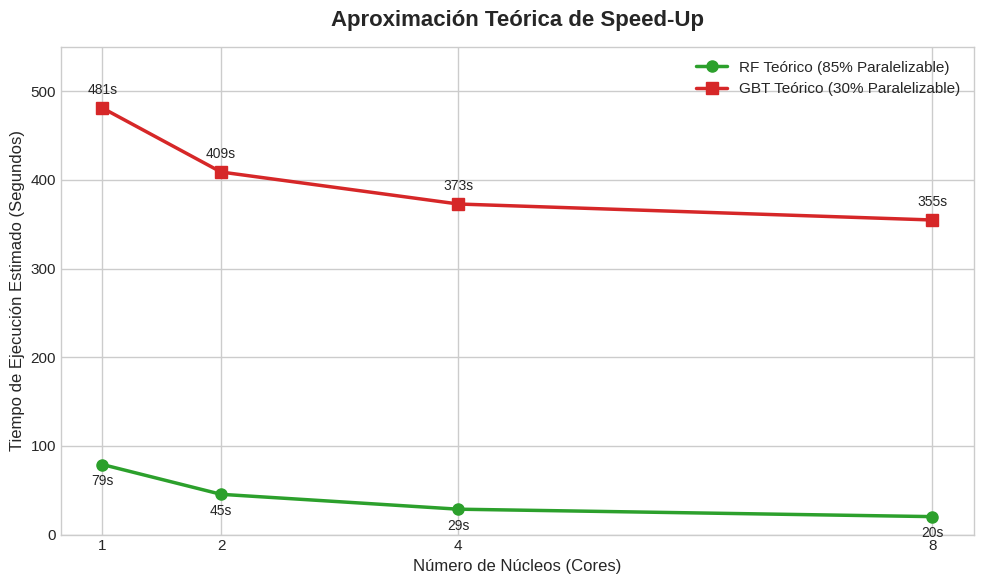

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Tiempos base empíricos obtenidos en vuestra prueba de Size-up (100% datos)
t1_rf = 79.0   # Tiempo RF con 1 core
t1_gbt = 481.0 # Tiempo GBT con 1 core

# Fracciones paralelizables (Asunciones teóricas basadas en la arquitectura)
p_rf = 0.85  # 85% paralelizable para RF
p_gbt = 0.30 # 30% paralelizable para GBT

# Eje X: Número de núcleos (Cores)
cores = np.array([1, 2, 4, 8])

# FÓRMULA DE LA LEY DE AMDAHL: T(N) = T(1) * ((1 - P) + P/N)
tiempo_teorico_rf = t1_rf * ((1 - p_rf) + (p_rf / cores))
tiempo_teorico_gbt = t1_gbt * ((1 - p_gbt) + (p_gbt / cores))

# Configuración del gráfico
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Dibujar las curvas de Speed-Up Teórico
plt.plot(cores, tiempo_teorico_rf, marker='o', linestyle='-', color='#2ca02c', linewidth=2.5, markersize=8, label='RF Teórico (85% Paralelizable)')
plt.plot(cores, tiempo_teorico_gbt, marker='s', linestyle='-', color='#d62728', linewidth=2.5, markersize=8, label='GBT Teórico (30% Paralelizable)')

# Añadir etiquetas de datos en los puntos para que se vean los tiempos exactos
for i, txt in enumerate(tiempo_teorico_rf):
    plt.annotate(f"{txt:.0f}s", (cores[i], tiempo_teorico_rf[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
for i, txt in enumerate(tiempo_teorico_gbt):
    plt.annotate(f"{txt:.0f}s", (cores[i], tiempo_teorico_gbt[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.title('Aproximación Teórica de Speed-Up', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número de Núcleos (Cores)', fontsize=12)
plt.ylabel('Tiempo de Ejecución Estimado (Segundos)', fontsize=12)
plt.xticks(cores)
plt.ylim(0, 550)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 8. Conclusiones del Proyecto: Predicción de Retrasos en Vuelos Comerciales

A partir del análisis y desarrollo de modelos predictivos utilizando Apache Spark sobre el conjunto de datos de vuelos comerciales de 2015, se han extraído las siguientes conclusiones clave:

## 8.1 Rendimiento de los Modelos Predictivos
* **Gradient-Boosted Trees (GBT):** Demostró ser el modelo más preciso, logrando el mejor rendimiento tras enriquecer los datos con un Área bajo la curva ROC (AUC) de **0.7025** y un PR AUC de **0.3959**.
* **Random Forest:** Presentó un rendimiento ligeramente inferior pero muy competitivo (AUC de 0.6920 y PR AUC de 0.3899).
* **Regresión Logística:** Actuó como modelo base (*baseline*), alcanzando un AUC de 0.6835. Los modelos basados en árboles demostraron superioridad al capturar relaciones complejas y no lineales entre las variables.

## 8.2 Variables Predictoras Clave (Feature Importance)
El modelo GBT reveló qué factores inciden más en que un vuelo no cumpla su horario programado:
* **Infraestructuras (Aeropuertos):** El aeropuerto de destino (26.6% de importancia) y el aeropuerto de origen (12.9%) demostraron ser los factores más determinantes debido a la congestión regional.
* **Efecto Dominó (Retrasos previos):** La variable operativa de arrastre de demora (`PREVIOUS_FLIGHT_DELAYED`) demostró tener un impacto altísimo (13.1%). Si la aeronave venía con retraso en una ruta previa, propaga esta disrupción.
* **Factores Temporales:** La hora programada de salida (`DEPARTURE_HOUR`, 11.4%) y el mes del vuelo (`MONTH`, 9.8%) son momentos temporales críticos en la logística aeroportuaria.
* **Efecto Congestión (Porcentaje de Vuelos):** Se creó la variable (`AIRPORT CONGESTED`). Se trata de una variable binaria que mide si el aeropuerto había sufrido un número de retrasos significativo en la anterior hora.
* **Condiciones Meteorológicas:** Las variables introducidas como la temperatura (8.8%), el mal tiempo (4.5%) y la velocidad del viento (2.6%) confirmaron la influencia climática en la puntualidad.

## 8.3 Escalabilidad Computacional y Eficiencia (Speed-up y Size-up)
La evaluación de los algoritmos de Spark frente a grandes volúmenes de datos reflejó contrastes arquitectónicos:
* **Random Forest:** Escala de manera sobresaliente. Al ser un modelo que construye múltiples árboles de decisión de forma independiente, es altamente paralelizable, permitiendo una reducción drástica de tiempos de cómputo al añadir núcleos o escalarlo en un clúster.
* **Gradient-Boosted Trees (GBT):** A pesar de su mayor exactitud, posee una naturaleza secuencial estricta (cada árbol intenta corregir el error del anterior). Esto impide que escale linealmente con más recursos y genera un alto coste de comunicación entre nodos (*overhead*), por lo que requiere mucho más tiempo de entrenamiento para asimilar grandes volúmenes de datos en comparación a Random Forest.

**Resumen:**
Para un entorno en producción donde la velocidad de entrenamiento es crucial y los recursos distribuidos son amplios, **Random Forest** es la solución más balanceada. Sin embargo, si la máxima precisión es el objetivo principal del negocio y el coste computacional no es una limitación, **GBT** se establece como el algoritmo definitivo para anticipar demoras operativas.